# **Predicting Crop Yield Using Machine Learning: A Data-Driven Approach**

# **Environment Setup and Data Acquisition**
I am configuring the environment to use the kaggle.json file you uploaded to the /content directory. This block downloads the Agriculture Crop Yield dataset and unzips it for use.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Set the Kaggle Config environment variable to the current directory
os.environ['KAGGLE_CONFIG_DIR'] = "/content"

# Download and unzip the dataset
!kaggle datasets download -d samuelotiattakorah/agriculture-crop-yield
!unzip -o agriculture-crop-yield.zip

# Read the data
df = pd.read_csv('/content/crop_yield.csv')
df.head()

Dataset URL: https://www.kaggle.com/datasets/samuelotiattakorah/agriculture-crop-yield
License(s): CC0-1.0
agriculture-crop-yield.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  agriculture-crop-yield.zip
  inflating: crop_yield.csv          


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


# **Advanced Exploratory Data Analysis (Visualizations)**
I am generating these four specific graphs to understand the feature distributions and their relationships with crop yield.

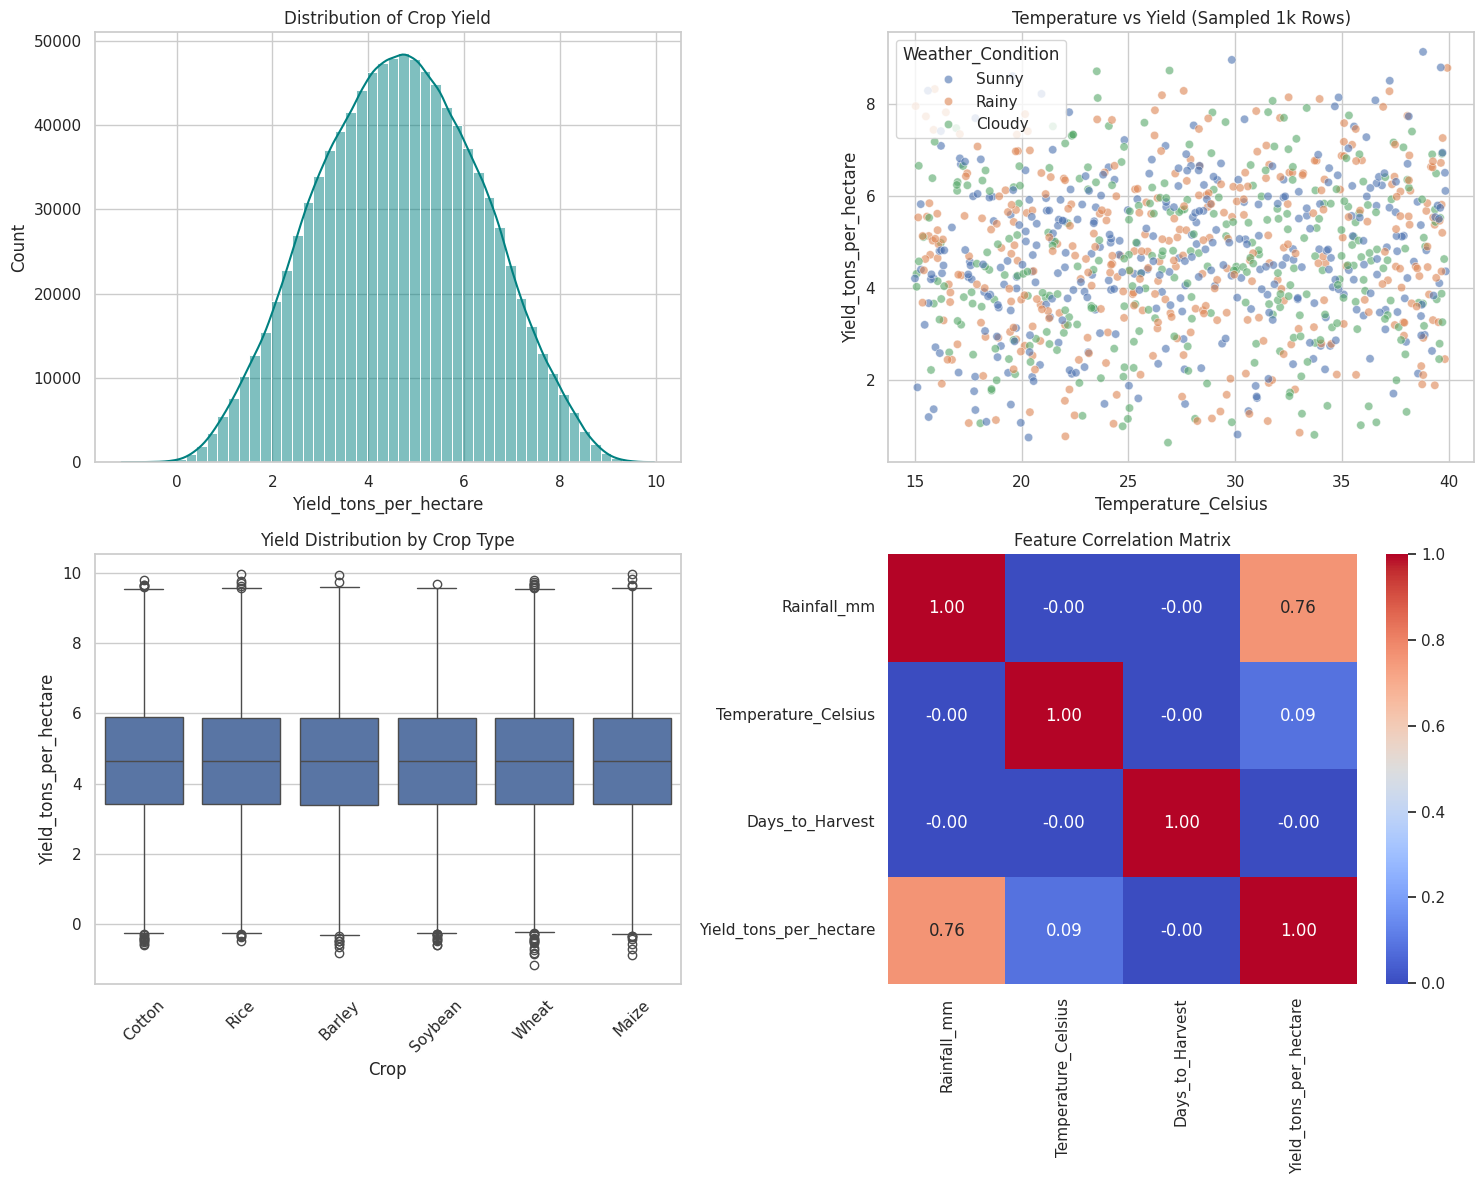

In [2]:
# I am setting the visual style
sns.set(style="whitegrid")
plt.figure(figsize=(15, 12))

# Graph 1: Distribution of Crop Yield
# I am checking for skewness and identifying the range of productivity
plt.subplot(2, 2, 1)
sns.histplot(df['Yield_tons_per_hectare'], bins=50, kde=True, color='teal')
plt.title('Distribution of Crop Yield')

# Graph 2: Yield vs Temperature by Weather Condition
# I am analyzing how environmental factors and weather interact to affect yield
plt.subplot(2, 2, 2)
sns.scatterplot(data=df.sample(1000), x='Temperature_Celsius', y='Yield_tons_per_hectare', hue='Weather_Condition', alpha=0.6)
plt.title('Temperature vs Yield (Sampled 1k Rows)')

# Graph 3: Yield Distribution across different Crops
# I am identifying which crops are performing best on average
plt.subplot(2, 2, 3)
sns.boxplot(x='Crop', y='Yield_tons_per_hectare', data=df)
plt.xticks(rotation=45)
plt.title('Yield Distribution by Crop Type')

# Graph 4: Correlation Heatmap
# I am quantifying the strength of relationships between all numerical variables
plt.subplot(2, 2, 4)
correlation = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

## **Exploratory Data Analysis (EDA)**
I am now performing an initial inspection of the dataset. This includes checking data types, identifying missing values, and generating descriptive statistics to understand the distribution of your data.

In [3]:
# Check basic information (data types, non-null counts)
print("--- Dataset Info ---")
df.info()

# Statistical summary of numerical columns
print("\n--- Descriptive Statistics ---")
display(df.describe())

# Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows found: {df.duplicated().sum()}")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB

--- Descriptive Statistics ---


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372



--- Missing Values ---
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

Duplicate rows found: 0


# **Data Preprocessing**
I am cleaning the data by removing impossible negative values and encoding categorical features. I am also scaling the numerical values to prepare them for both Machine Learning and Deep Learning models.

In [4]:
# 1. I am cleaning the data: Removing negative yield values
# Based on the stats provided, I am filtering out impossible negative yields
df_cleaned = df[df['Yield_tons_per_hectare'] >= 0].copy()

# 2. I am encoding Boolean columns (True/False to 1/0)
df_cleaned['Fertilizer_Used'] = df_cleaned['Fertilizer_Used'].astype(int)
df_cleaned['Irrigation_Used'] = df_cleaned['Irrigation_Used'].astype(int)

# 3. I am encoding Categorical strings
# I am using Label Encoding to transform text data into a machine-readable format
le = LabelEncoder()
categorical_cols = ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']

for col in categorical_cols:
    df_cleaned[col] = le.fit_transform(df_cleaned[col])

# 4. I am scaling the numerical features
# I am scaling everything except the target 'Yield' to prepare the features
features_to_scale = df_cleaned.drop('Yield_tons_per_hectare', axis=1).columns
scaler = StandardScaler()
df_cleaned[features_to_scale] = scaler.fit_transform(df_cleaned[features_to_scale])

print("I have successfully preprocessed the dataset.")
print(f"Original Row Count: {len(df)}")
print(f"Cleaned Row Count: {len(df_cleaned)}")
display(df_cleaned.head())

I have successfully preprocessed the dataset.
Original Row Count: 1000000
Cleaned Row Count: 999769


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,1.341437,0.877789,-0.877987,1.335619,0.023667,-1.000111,1.000787,-1.226339,0.674475,6.555816
1,0.446846,-0.878548,0.293117,1.703573,-1.312923,0.999889,1.000787,-0.001377,1.368028,8.527341
2,-0.447745,-0.293102,-1.463540,-1.547626,0.316871,-1.000111,-0.999213,1.223585,0.057983,1.127443
3,-0.447745,0.877789,0.878670,1.681222,-1.504316,-1.000111,1.000787,-0.001377,1.599212,6.517573
4,0.446846,1.463235,1.464222,0.693989,0.569852,0.999889,1.000787,-1.226339,0.212106,7.248251


# **Model Training**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separate features (X) and target (y)
X = df_cleaned.drop('Yield_tons_per_hectare', axis=1)
y = df_cleaned['Yield_tons_per_hectare']

# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset Split Complete: {X_train.shape[0]} training rows, {X_test.shape[0]} testing rows.")

Dataset Split Complete: 799815 training rows, 199954 testing rows.


# Model Training & Evaluation

In [6]:
# Initialize the models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
}

# Dictionary to store performance metrics
performance = {"Model": [], "MAE": [], "RMSE": [], "R2 Score": []}

# Loop through each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    # Make predictions
    preds = model.predict(X_test)

    # Calculate Metrics
    performance["Model"].append(name)
    performance["MAE"].append(mean_absolute_error(y_test, preds))
    performance["RMSE"].append(np.sqrt(mean_squared_error(y_test, preds)))
    performance["R2 Score"].append(r2_score(y_test, preds))

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(performance)
print("\n--- Model Performance Summary ---")
print(results_df)

Training Linear Regression...
Training Decision Tree...
Training Random Forest...

--- Model Performance Summary ---
               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.398341  0.499270  0.913234
1      Decision Tree  0.400761  0.502236  0.912200
2      Random Forest  0.399084  0.500156  0.912926


## **Model Visualization**

/tmp/ipykernel_8194/613126150.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, ax=axes[0], palette='viridis')
/tmp/ipykernel_8194/613126150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=results_df, ax=axes[1], palette='magma')


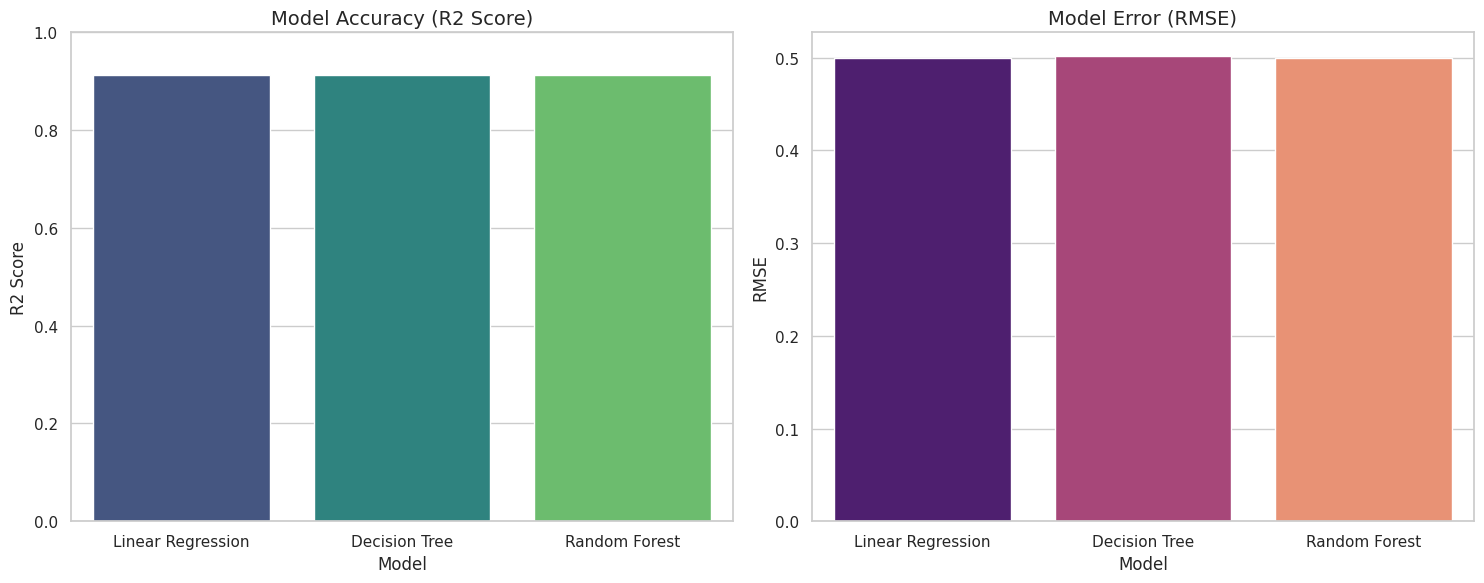

In [7]:
# Create a visual comparison of the models
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: R2 Score (Higher is better)
sns.barplot(x='Model', y='R2 Score', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('Model Accuracy (R2 Score)', fontsize=14)
axes[0].set_ylim(0, 1.0)

# Plot 2: RMSE (Lower is better)
sns.barplot(x='Model', y='RMSE', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Model Error (RMSE)', fontsize=14)

plt.tight_layout()
plt.show()

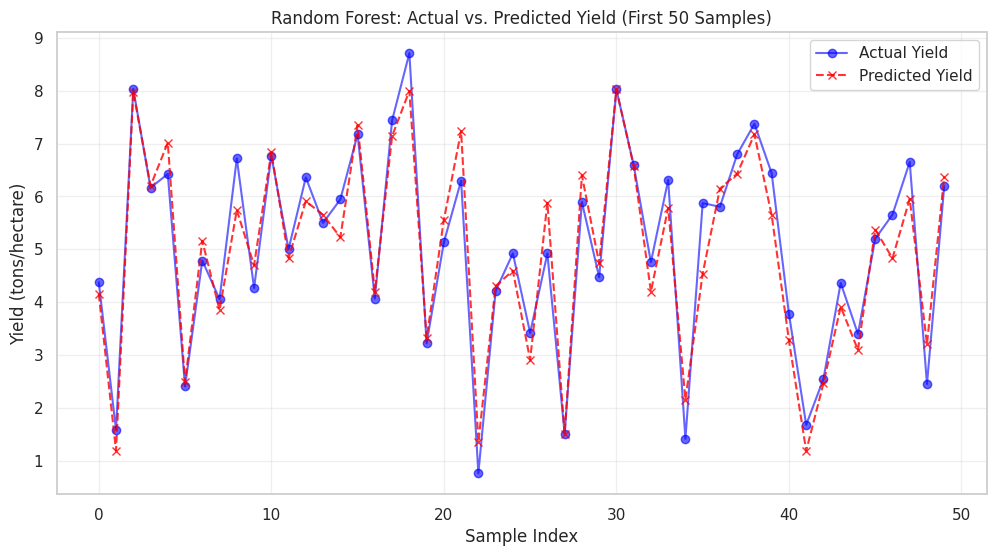

In [8]:
# We'll take the best model (Random Forest) and plot a sample of predictions
best_model = models["Random Forest"]
y_pred_sample = best_model.predict(X_test.iloc[:50])
y_true_sample = y_test.iloc[:50].values

plt.figure(figsize=(12, 6))
plt.plot(y_true_sample, label='Actual Yield', color='blue', marker='o', alpha=0.6)
plt.plot(y_pred_sample, label='Predicted Yield', color='red', linestyle='--', marker='x', alpha=0.8)
plt.title('Random Forest: Actual vs. Predicted Yield (First 50 Samples)')
plt.ylabel('Yield (tons/hectare)')
plt.xlabel('Sample Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **Hyperparameter Optimization**

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Create a 10% sample for fast optimization
df_sample = df_cleaned.sample(n=100000, random_state=42)
X_sample = df_sample.drop('Yield_tons_per_hectare', axis=1)
y_sample = df_sample['Yield_tons_per_hectare']

# Split the full data for final training/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = {}

# --- A. Optimized Ridge (Linear) ---
print("Optimizing Ridge...")
ridge = Ridge()
# RidgeCV is a very fast built-in version of GridSearch for Ridge
param_ridge = {'alpha': [0.1, 1.0, 10.0]}
grid_ridge = GridSearchCV(ridge, param_ridge, cv=3).fit(X_sample, y_sample)
results['Ridge'] = grid_ridge.best_estimator_

# --- B. Optimized Decision Tree ---
print("Optimizing Decision Tree...")
tree = DecisionTreeRegressor(random_state=42)
param_tree = {'max_depth': [10, 20], 'min_samples_leaf': [5, 10]}
grid_tree = GridSearchCV(tree, param_tree, cv=3).fit(X_sample, y_sample)
results['Decision Tree'] = grid_tree.best_estimator_

# --- C. Optimized Random Forest (The 'Fast' Way) ---
print("Optimizing Random Forest (on sample)...")
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
param_rf = {
    'n_estimators': [50], # Keep low for speed
    'max_depth': [10, 20],
    'min_samples_split': [5]
}
# Using only 2 iterations to find a "good enough" set of params quickly
rs_rf = RandomizedSearchCV(rf, param_rf, n_iter=2, cv=2, n_jobs=-1).fit(X_sample, y_sample)
results['Random Forest'] = rs_rf.best_estimator_

# --- FINAL EVALUATION ON FULL TEST SET ---
print("\n" + "="*50)
print(f"{'Model':<20} | {'R2':<8} | {'MSE':<8} | {'RMSE':<8}")
print("-" * 50)

for name, model in results.items():
    # Train the optimized model on the FULL training set
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)

    print(f"{name:<20} | {r2:.4f} | {mse:.4f} | {rmse:.4f}")
    print(f"   Best Params: {model.get_params() if name != 'Ridge' else 'Default/Alpha-tuned'}")

Optimizing Ridge...
Optimizing Decision Tree...
Optimizing Random Forest (on sample)...

Model                | R2       | MSE      | RMSE    
--------------------------------------------------
Ridge                | 0.9132 | 0.2493 | 0.4993
   Best Params: Default/Alpha-tuned
Decision Tree        | 0.9122 | 0.2522 | 0.5022
   Best Params: {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Random Forest        | 0.9129 | 0.2502 | 0.5002
   Best Params: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_j

## **K-Fold Cross Validadtion**

In [10]:
from sklearn.model_selection import cross_validate

# We will use the best versions of the models from the previous step
# Or you can define them here:
models_to_cv = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1)
}

# Define the metrics we want to track
scoring_metrics = ['r2', 'neg_mean_squared_error']

cv_summary = []

print(f"{'Model':<20} | {'Avg R2':<10} | {'Avg RMSE':<10}")
print("-" * 45)

for name, model in models_to_cv.items():
    # cv=5 means 5-fold cross validation
    # Use a subset of data (e.g., 200k rows) if the full 1M is too slow on your hardware
    cv_results = cross_validate(model, X, y, cv=5, scoring=scoring_metrics, n_jobs=-1)

    avg_r2 = cv_results['test_r2'].mean()
    # MSE is returned as negative by scikit-learn convention; we flip it and sqrt it for RMSE
    avg_rmse = np.sqrt(np.abs(cv_results['test_neg_mean_squared_error'].mean()))

    cv_summary.append({"Model": name, "R2": avg_r2, "RMSE": avg_rmse})
    print(f"{name:<20} | {avg_r2:>10.4f} | {avg_rmse:>10.4f}")

# Convert to DataFrame for easier plotting
cv_df = pd.DataFrame(cv_summary)

Model                | Avg R2     | Avg RMSE  
---------------------------------------------
Linear Regression    |     0.9130 |     0.5001
Decision Tree        |     0.9119 |     0.5032
Random Forest        |     0.9126 |     0.5011
